# Vancouver Housing Insights

## What Drives Vancouver Housing Prices?

This report presents a comprehensive data-driven narrative around Vancouver property land values
We bring together four datasets: property tax records, crime incidents, business licences, and local area boundaries to uncover the key factors that shape land prices across the city

**Business Questions Answered**:
1. How are land values distributed across Vancouver neighbourhoods?
2. Does crime rate negatively affect land values?
3. Does business activity correlate with higher land values?

In [1]:
# imports
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings('ignore')

# report-wide style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif'})

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'data', 'staging'))


## Dataset Overview

In [2]:
# load all staging datasets
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'data', 'staging'))

datasets = {
    'property_tax': 'property_tax_transformed_*.csv',
    'crime': 'crime_transformed_*.csv',
    'business': 'business_licences_transformed_*.csv',
    'local_areas': 'local_areas_transformed_*.csv'
}

def get_latest_file(base_dir, pattern):
    files = glob.glob(os.path.join(base_dir, pattern))
    if not files:
        raise FileNotFoundError(f"Cannot file with this pattern: {pattern}")
    return sorted(files, reverse=True)[0]

data_frames = {}

for key, pattern in datasets.items():
    file_path = get_latest_file(BASE_DIR, pattern)
    low_memory = False if key != 'local_areas' else True
    data_frames[key] = pd.read_csv(file_path, low_memory=low_memory)
    print(f"{key.ljust(13)} : {data_frames[key].shape} (Loaded: {os.path.basename(file_path)})")

property_tax = data_frames['property_tax']
crime = data_frames['crime']
business = data_frames['business']
local_areas = data_frames['local_areas']

property_tax  : (1551459, 26) (Loaded: property_tax_transformed_20260329.csv)
crime         : (878643, 6) (Loaded: crime_transformed_20260329.csv)
business      : (248117, 25) (Loaded: business_licences_transformed_20260329.csv)
local_areas   : (22, 4) (Loaded: local_areas_transformed_20260329.csv)


In [3]:
# feature engineering
crime['neighbourhood'] = crime['neighbourhood'].str.strip().str.title()
business['local_area'] = business['local_area'].str.strip().str.title()
local_areas['name']    = local_areas['name'].str.strip().str.title()

crime_count = (
    crime.groupby('neighbourhood', as_index=False)
    .size()
    .rename(columns={'neighbourhood': 'name', 'size': 'total_crimes'})
)
active_business = business[business['status'].str.lower().isin(['issued', 'renewed'])]
business_count = (
    active_business.groupby('local_area', as_index=False)
    .size()
    .rename(columns={'local_area': 'name', 'size': 'business_count'})
)

neighbourhood_features = (
    local_areas[['name', 'center_lat', 'center_lon']]
    .merge(crime_count,    on='name', how='left')
    .merge(business_count, on='name', how='left')
)
neighbourhood_features['total_crimes']   = neighbourhood_features['total_crimes'].fillna(0)
neighbourhood_features['business_count'] = neighbourhood_features['business_count'].fillna(0)

unique_codes = sorted(property_tax['neighbourhood_code'].dropna().unique())
unique_names = sorted(neighbourhood_features['name'].unique())
min_len      = min(len(unique_codes), len(unique_names))
code_to_name = dict(zip(unique_codes[:min_len], unique_names[:min_len]))

neighbourhood_property = (
    property_tax
    .dropna(subset=['current_land_value'])
    .assign(neighbourhood_code=lambda d: d['neighbourhood_code'].astype(int))
    .groupby('neighbourhood_code', as_index=False)
    .agg(
        median_land_value=('current_land_value', 'median'),
        mean_land_value  =('current_land_value', 'mean'),
        property_count   =('current_land_value', 'count'),
        top_zoning       =('zoning_classification', lambda x: x.mode()[0] if x.notna().any() else 'Unknown')
    )
)
neighbourhood_property['name'] = neighbourhood_property['neighbourhood_code'].map(code_to_name)
neighbourhood_property = neighbourhood_property.dropna(subset=['name'])

neighbourhood_ml = neighbourhood_property.merge(
    neighbourhood_features[['name', 'total_crimes', 'business_count', 'center_lat', 'center_lon']],
    on='name', how='left'
)
neighbourhood_ml['crime_rate']       = neighbourhood_ml['total_crimes']   / neighbourhood_ml['property_count'] * 1000
neighbourhood_ml['business_density'] = neighbourhood_ml['business_count'] / neighbourhood_ml['property_count'] * 1000
neighbourhood_ml = neighbourhood_ml.dropna(subset=['crime_rate', 'business_density'])

## Land Value Distribution Across Vancouver

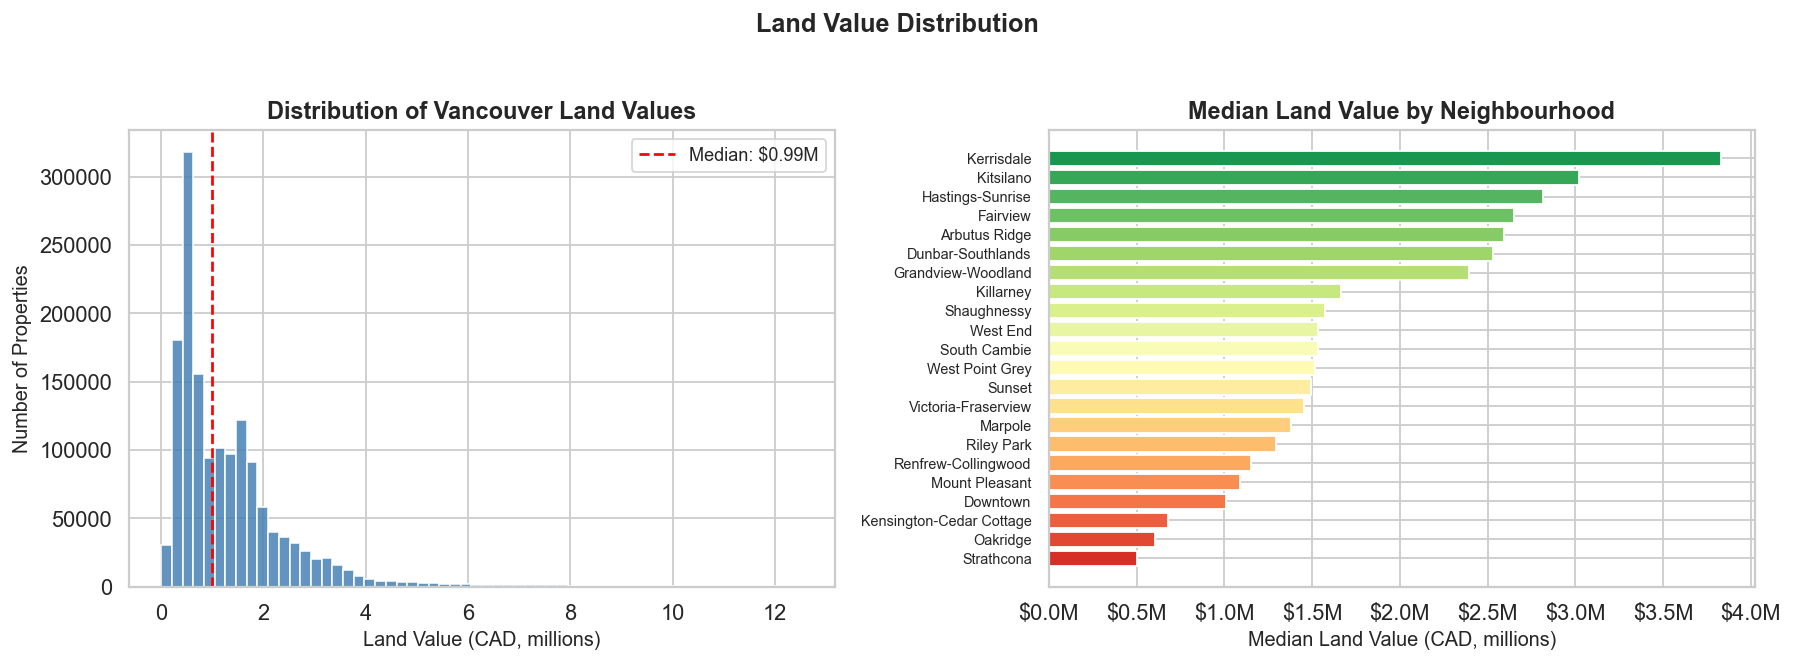

Overall median land value: $993,000
Overall mean land value: $1,358,406


In [4]:
# filter valid land value rows and cap at 99
lv = property_tax['current_land_value'].dropna()
cap = lv.quantile(0.99)
lv_capped = lv[lv <= cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
ax = axes[0]
ax.hist(lv_capped / 1e6, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(lv_capped.median() / 1e6, color='red', linestyle='--', linewidth=1.5,
           label=f'Median: ${lv_capped.median()/1e6:.2f}M')
ax.set_xlabel('Land Value (CAD, millions)', fontsize=11)
ax.set_ylabel('Number of Properties', fontsize=11)
ax.set_title('Distribution of Vancouver Land Values', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# bar chart: median land value by neighbourhood (top 22)
ax = axes[1]
nb_sorted = neighbourhood_ml.sort_values('median_land_value', ascending=True)
colors_bar = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(nb_sorted)))
bars = ax.barh(nb_sorted['name'], nb_sorted['median_land_value'] / 1e6, color=colors_bar)
ax.set_xlabel('Median Land Value (CAD, millions)', fontsize=11)
ax.set_title('Median Land Value by Neighbourhood', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Land Value Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Overall median land value: ${lv_capped.median():,.0f}')
print(f'Overall mean land value: ${lv_capped.mean():,.0f}')

## Crime Rate vs Land Value

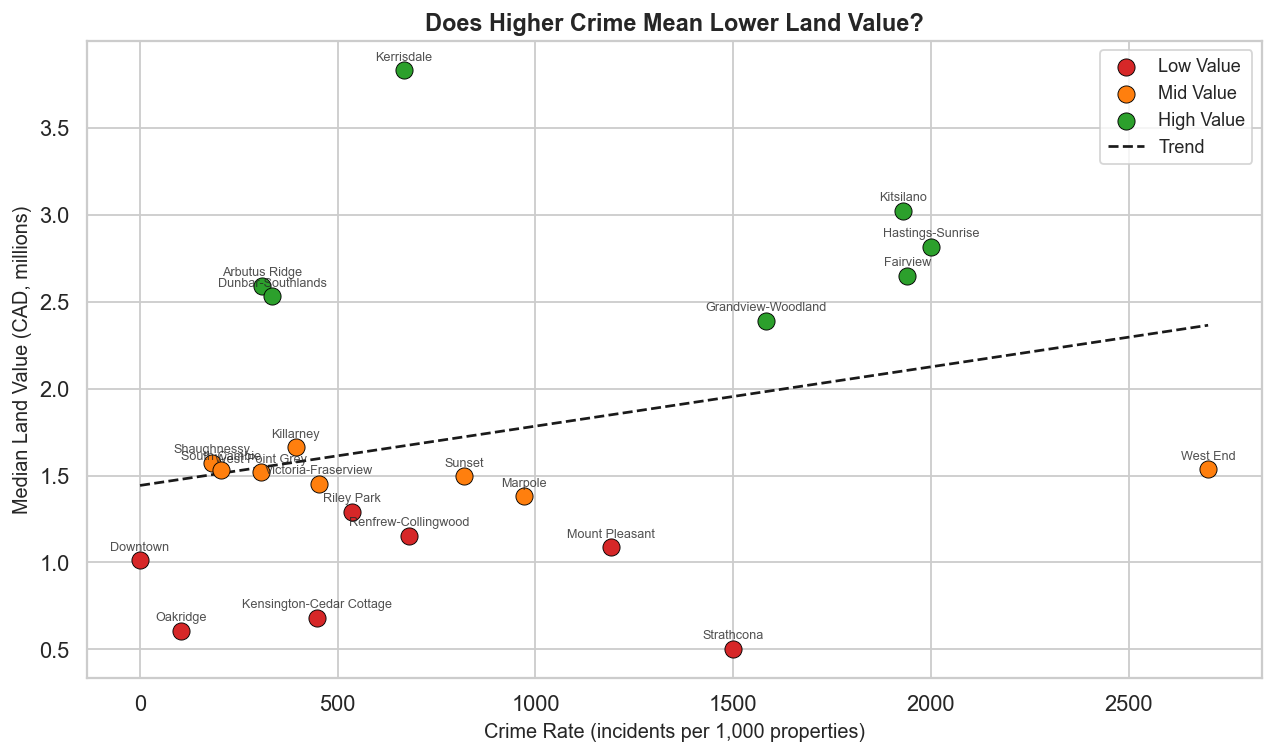

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# colour points by land value tier
q33 = neighbourhood_ml['median_land_value'].quantile(0.33)
q67 = neighbourhood_ml['median_land_value'].quantile(0.67)

def tier(val):
    if val < q33:   return 'Low Value'
    if val < q67:   return 'Mid Value'
    return 'High Value'

neighbourhood_ml['tier'] = neighbourhood_ml['median_land_value'].apply(tier)
tier_colors = {'Low Value': '#d62728', 'Mid Value': '#ff7f0e', 'High Value': '#2ca02c'}

for t, color in tier_colors.items():
    sub = neighbourhood_ml[neighbourhood_ml['tier'] == t]
    ax.scatter(sub['crime_rate'], sub['median_land_value'] / 1e6,
               color=color, s=90, label=t, edgecolors='black', linewidths=0.5, zorder=3)

# trend line
m, b = np.polyfit(neighbourhood_ml['crime_rate'].fillna(0),
                   neighbourhood_ml['median_land_value'].fillna(0) / 1e6, 1)
x_r = np.linspace(neighbourhood_ml['crime_rate'].min(), neighbourhood_ml['crime_rate'].max(), 100)
ax.plot(x_r, m * x_r + b, 'k--', linewidth=1.5, label='Trend')

# annotate
for _, row in neighbourhood_ml.iterrows():
    ax.annotate(row['name'], (row['crime_rate'], row['median_land_value'] / 1e6),
                fontsize=7, alpha=0.8, ha='center', va='bottom', xytext=(0, 4),
                textcoords='offset points')

ax.set_xlabel('Crime Rate (incidents per 1,000 properties)', fontsize=11)
ax.set_ylabel('Median Land Value (CAD, millions)', fontsize=11)
ax.set_title('Does Higher Crime Mean Lower Land Value?', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Business Density vs Land Value

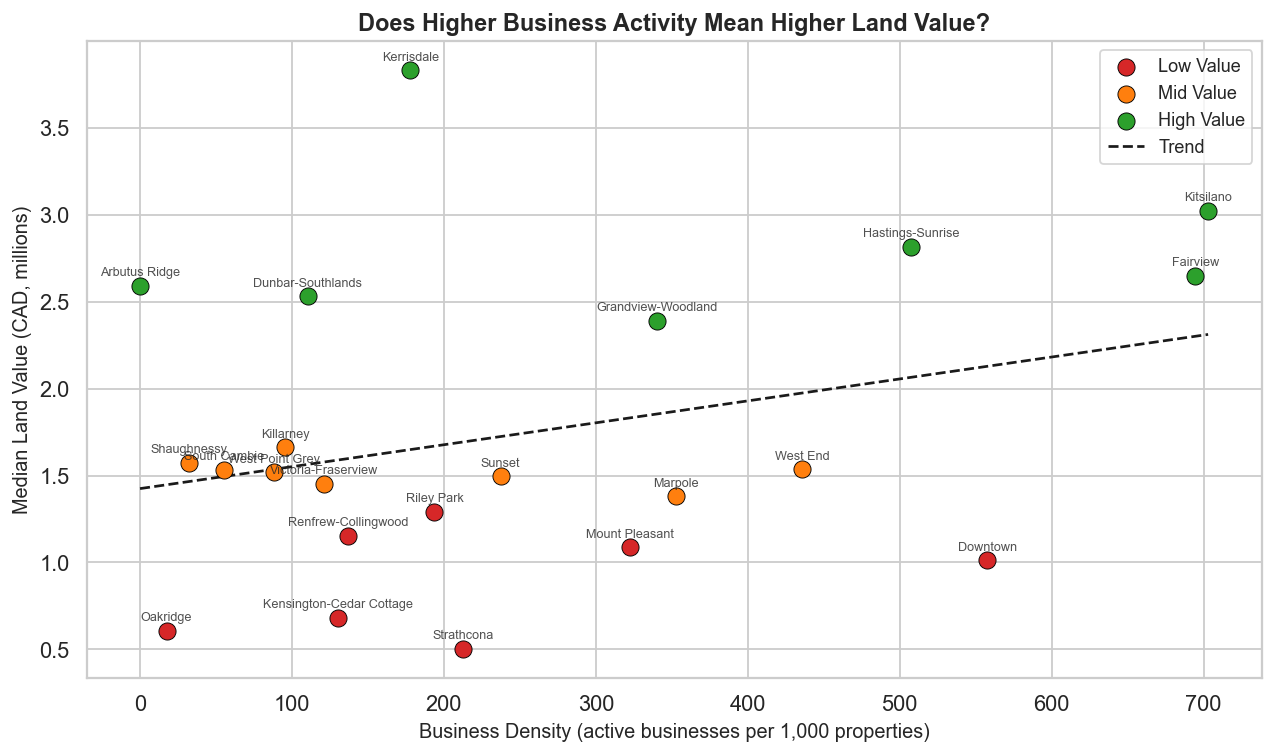

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for t, color in tier_colors.items():
    sub = neighbourhood_ml[neighbourhood_ml['tier'] == t]
    ax.scatter(sub['business_density'], sub['median_land_value'] / 1e6,
               color=color, s=90, label=t, edgecolors='black', linewidths=0.5, zorder=3)

# trend line
m2, b2 = np.polyfit(neighbourhood_ml['business_density'].fillna(0),
                     neighbourhood_ml['median_land_value'].fillna(0) / 1e6, 1)
x_r2 = np.linspace(neighbourhood_ml['business_density'].min(), neighbourhood_ml['business_density'].max(), 100)
ax.plot(x_r2, m2 * x_r2 + b2, 'k--', linewidth=1.5, label='Trend')

for _, row in neighbourhood_ml.iterrows():
    ax.annotate(row['name'], (row['business_density'], row['median_land_value'] / 1e6),
                fontsize=7, alpha=0.8, ha='center', va='bottom', xytext=(0, 4),
                textcoords='offset points')

ax.set_xlabel('Business Density (active businesses per 1,000 properties)', fontsize=11)
ax.set_ylabel('Median Land Value (CAD, millions)', fontsize=11)
ax.set_title('Does Higher Business Activity Mean Higher Land Value?', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Crime Type Analysis 
Commend: I am not sure we should include this, Im drawed this just because it looks clean and beauty =)))

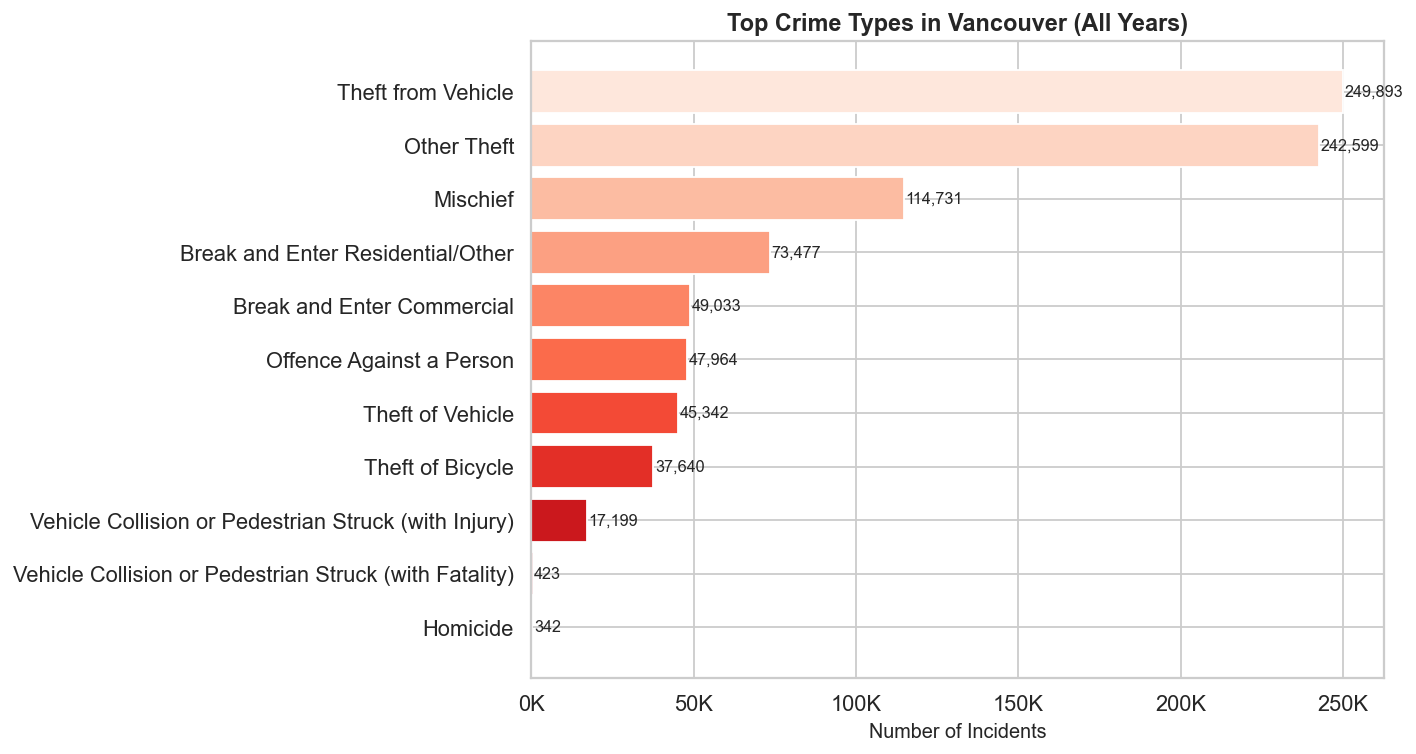

In [7]:
# top crime types across all of Vancouver
crime_type_counts = crime['type'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    crime_type_counts.index[::-1],
    crime_type_counts.values[::-1],
    color=sns.color_palette('Reds_r', len(crime_type_counts))
)
for bar, val in zip(bars, crime_type_counts.values[::-1]):
    ax.text(val + 500, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Number of Incidents', fontsize=11)
ax.set_title('Top Crime Types in Vancouver (All Years)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## Most Significant Findings & Data-Driven Recommendations

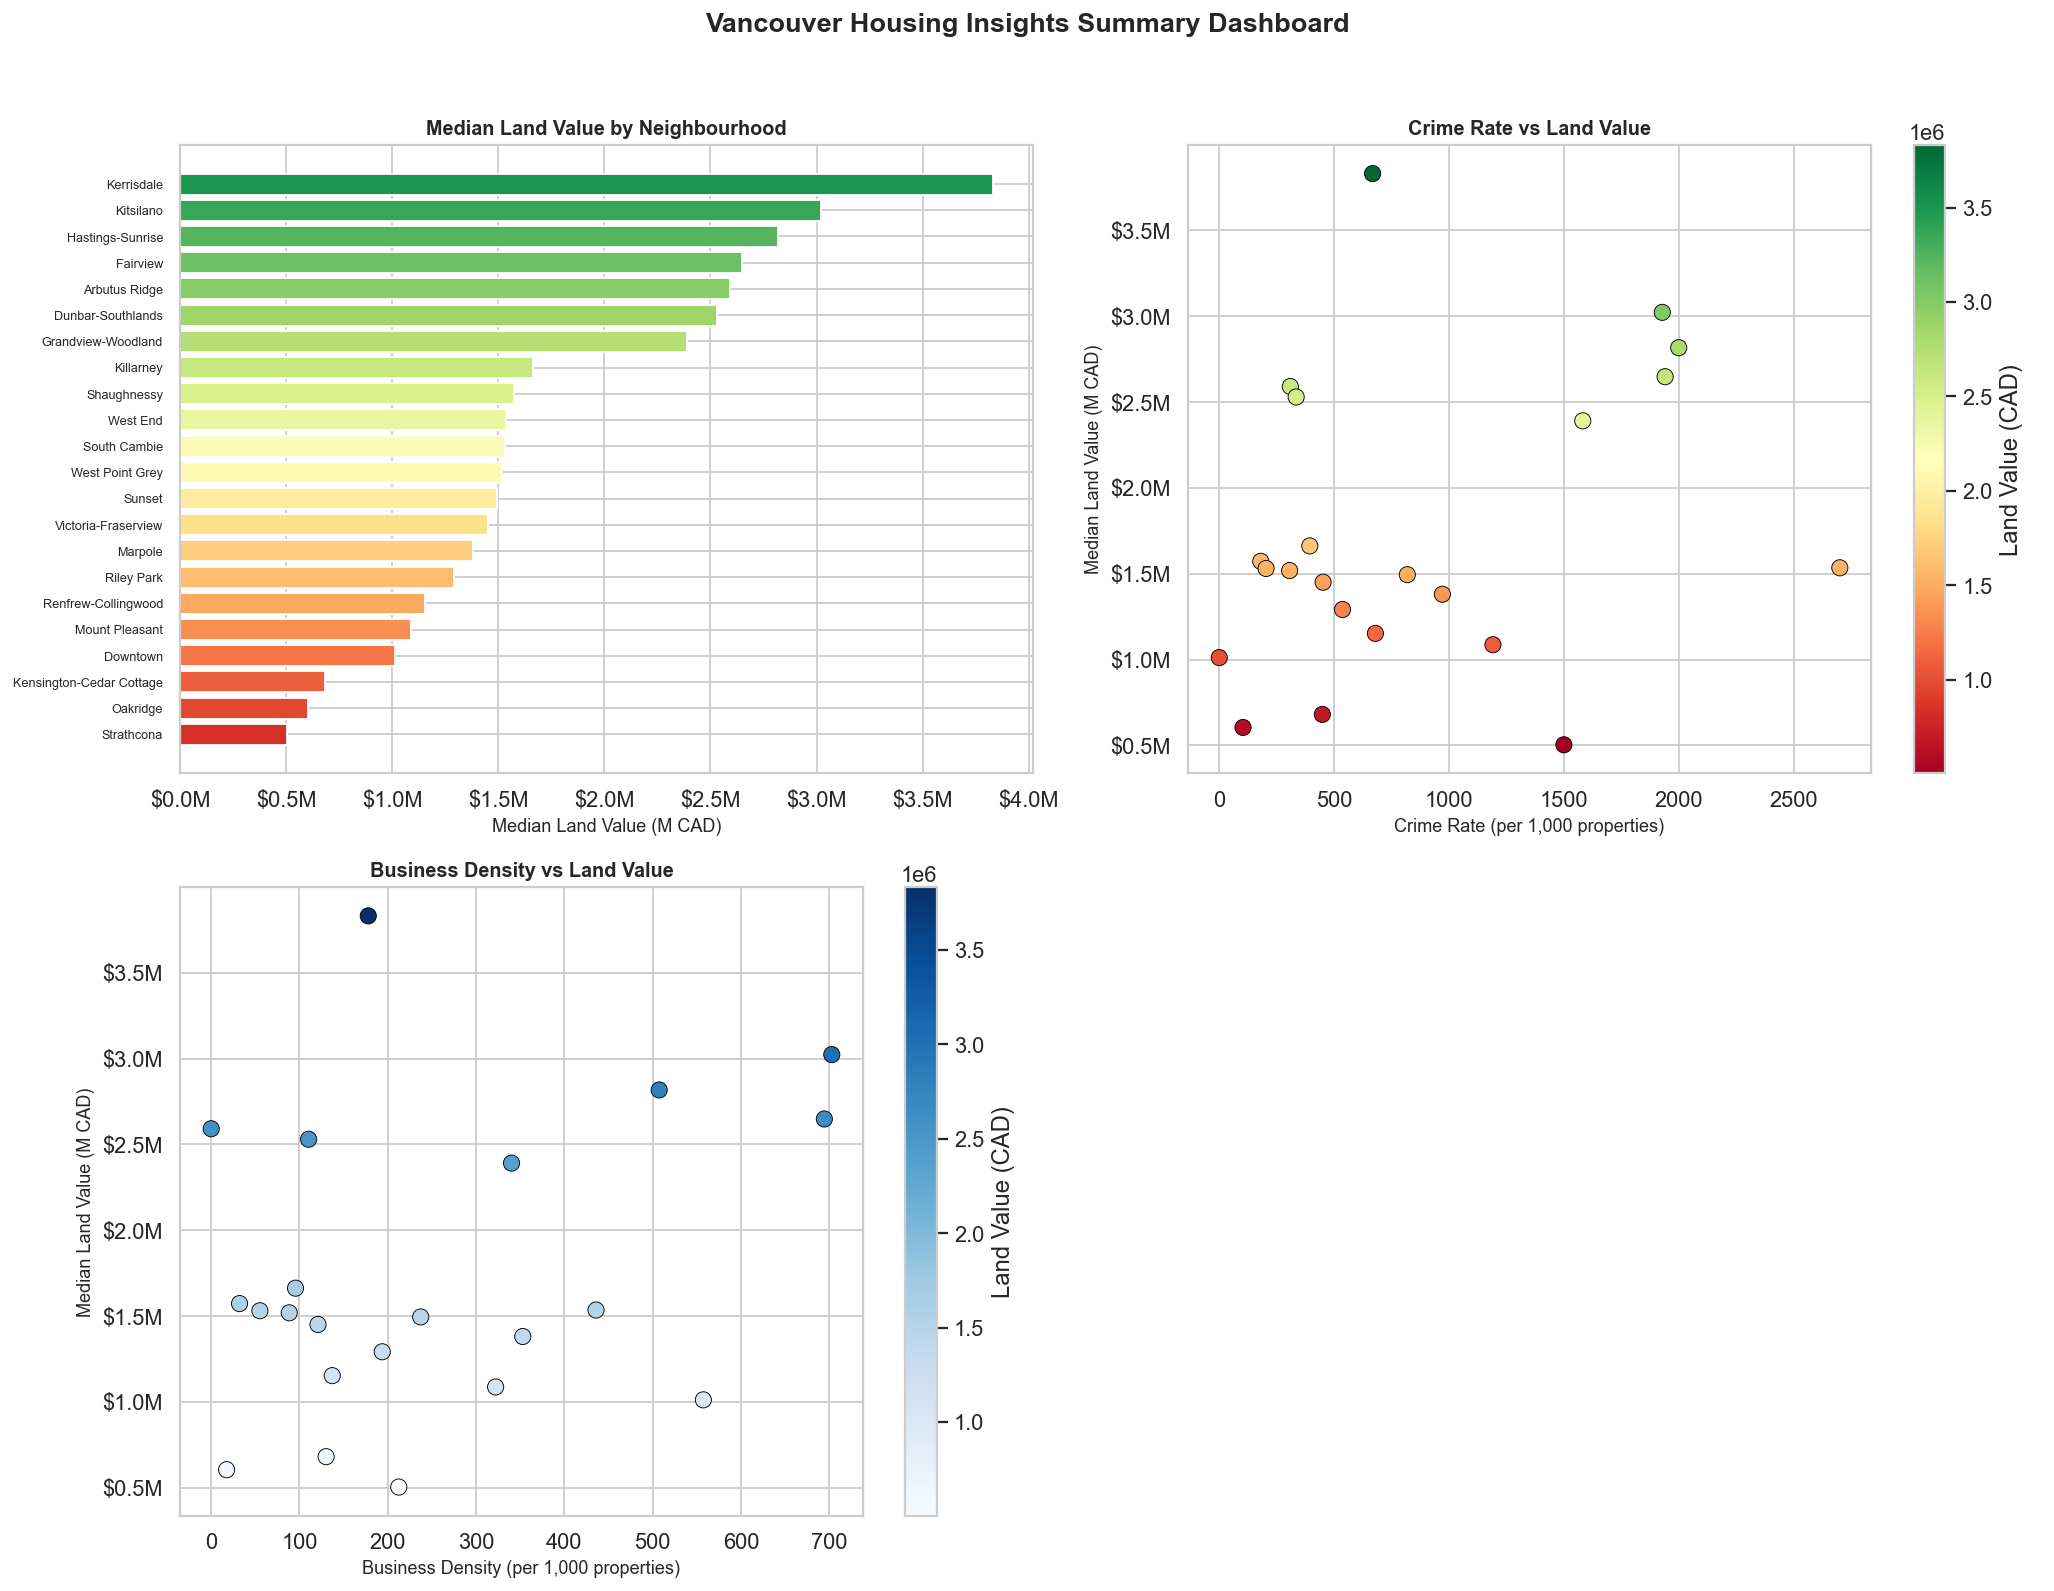

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# land value by neighbourhood (horizontal bar)
ax = axes[0, 0]
nb_s = neighbourhood_ml.sort_values('median_land_value')
c = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(nb_s)))
ax.barh(nb_s['name'], nb_s['median_land_value'] / 1e6, color=c)
ax.set_xlabel('Median Land Value (M CAD)', fontsize=10)
ax.set_title('Median Land Value by Neighbourhood', fontsize=11, fontweight='bold')
ax.tick_params(axis='y', labelsize=7)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# crime rate vs land value
ax = axes[0, 1]
sc = ax.scatter(
    neighbourhood_ml['crime_rate'],
    neighbourhood_ml['median_land_value'] / 1e6,
    c=neighbourhood_ml['median_land_value'],
    cmap='RdYlGn', s=80, edgecolors='black', linewidths=0.5
)
plt.colorbar(sc, ax=ax, label='Land Value (CAD)')
ax.set_xlabel('Crime Rate (per 1,000 properties)', fontsize=10)
ax.set_ylabel('Median Land Value (M CAD)', fontsize=10)
ax.set_title('Crime Rate vs Land Value', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# business density vs land value
ax = axes[1, 0]
sc2 = ax.scatter(
    neighbourhood_ml['business_density'],
    neighbourhood_ml['median_land_value'] / 1e6,
    c=neighbourhood_ml['median_land_value'],
    cmap='Blues', s=80, edgecolors='black', linewidths=0.5
)
plt.colorbar(sc2, ax=ax, label='Land Value (CAD)')
ax.set_xlabel('Business Density (per 1,000 properties)', fontsize=10)
ax.set_ylabel('Median Land Value (M CAD)', fontsize=10)
ax.set_title('Business Density vs Land Value', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

axes[1, 1].axis('off')
plt.suptitle('Vancouver Housing Insights Summary Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()